In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
# --- Config ---
# Nama file kunci jawaban
ANSWER_KEY_FILE = "Kunci Jawaban BDC 2026(Kunci Jawaban).csv"

# Daftar file prediksi yang mau dievaluasi
SUBMISSION_FILES = [
    "submission_baseline.csv",
    "submission_advanced.csv",
    "submission_cutmix.csv"
]

true_df = pd.read_csv(ANSWER_KEY_FILE)
true_df = true_df.sort_values("id")
y_true = true_df["Code"].values
true_ids = true_df["id"].values

print(f"Total data di kunci jawaban: {len(y_true)}")

class_names = ["0_Recyclable", "1_Electronic", "2_Organic"]

Total data di kunci jawaban: 1458


EVALUASI FILE: submission_baseline.csv
Total Jawaban Benar: 1377 dari 1458 gambar
Akurasi Keseluruhan: 94.44%

Detail Performa per Kelas:
              precision    recall  f1-score   support

0_Recyclable       0.98      0.87      0.92       549
1_Electronic       0.95      1.00      0.97       201
   2_Organic       0.92      0.99      0.95       708

    accuracy                           0.94      1458
   macro avg       0.95      0.95      0.95      1458
weighted avg       0.95      0.94      0.94      1458



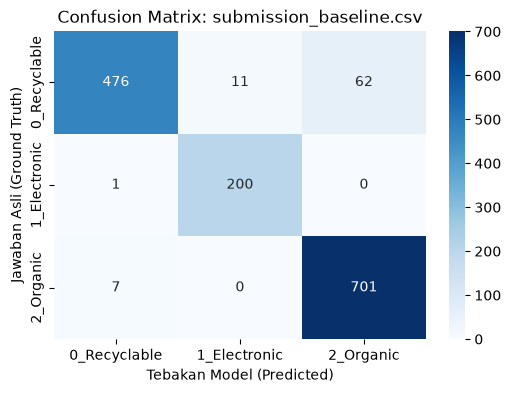



EVALUASI FILE: submission_advanced.csv

[WARNING] Ada pergeseran indeks gara-gara file .DS_Store Mac. Gua otomatis turunin indeksnya biar cocok!

Total Jawaban Benar: 1358 dari 1458 gambar
Akurasi Keseluruhan: 93.14%

Detail Performa per Kelas:
              precision    recall  f1-score   support

0_Recyclable       0.98      0.83      0.90       549
1_Electronic       0.99      0.99      0.99       201
   2_Organic       0.89      0.99      0.94       708

    accuracy                           0.93      1458
   macro avg       0.95      0.94      0.94      1458
weighted avg       0.94      0.93      0.93      1458



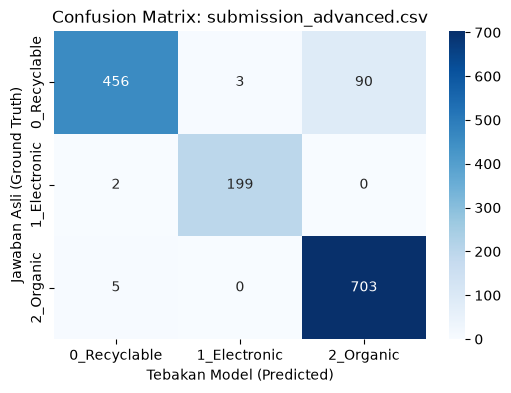




[SKIP] File submission_cutmix.csv belum ada. Lewatin dulu...


In [5]:
# --- Evaluasi Semua Model ---
for sub_file in SUBMISSION_FILES:
    if not os.path.exists(sub_file):
        print(f"\n[SKIP] File {sub_file} belum ada. Lewatin dulu...")
        continue
        
    print("="*60)
    print(f"EVALUASI FILE: {sub_file}")
    print("="*60)
    
    pred_df = pd.read_csv(sub_file)
    pred_df = pred_df.sort_values("id")
    
    if not np.array_equal(pred_df["id"].values, true_ids):
        print("ERROR: Urutan atau jumlah ID di file submission ini beda sama kunci jawaban!")
        continue
        
    y_pred = pred_df["predicted"].values
    
    # FIX MAC .DS_Store BUGS BEFORE CALCULATING ACCURACY
    if y_pred.max() == 3:
        print("\n[WARNING] Ada pergeseran indeks gara-gara file .DS_Store Mac. Gua otomatis turunin indeksnya biar cocok!\n")
        y_pred = y_pred - 1
    
    acc = accuracy_score(y_true, y_pred)
    total_benar = np.sum(y_true == y_pred)
    
    print(f"Total Jawaban Benar: {total_benar} dari {len(y_true)} gambar")
    print(f"Akurasi Keseluruhan: {acc*100:.2f}%\n")
    
    print("Detail Performa per Kelas:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix: {sub_file}")
    plt.ylabel("Jawaban Asli (Ground Truth)")
    plt.xlabel("Tebakan Model (Predicted)")
    plt.show()
    print("\n")